In [1]:
from google.colab import drive
drive.mount('/gdrive', force_remount = True)
!ls '/gdrive/My Drive'
%cd '/gdrive/My Drive'

ModuleNotFoundError: No module named 'google.colab'

In [1]:
import torch
import math
import random
from torch import nn
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt

In [2]:
trained = False
epochs = 50
display_step = 25
img_channels = 1
crit_repeats = 5
learning_rate_D = 0.0002
learning_rate_G = 0.001
beta_1 = 0.0
beta_2 = 0.9
lambda_ = 10
z_dim = 100
device = 'cuda'
loss = 'W'
size = (1, 128, 128)
image_size = 128
batch_size = 64

In [3]:
DATA_DIR = 'TestDataset'
stats = (0.5), (0.5)

In [4]:
train_ds = ImageFolder(DATA_DIR, transform = T.Compose([
    T.Grayscale(num_output_channels = 1),
    T.Resize(image_size),
    T.CenterCrop(image_size),
    T.ToTensor(),
    T.Normalize(*stats)])
)

dataloader = DataLoader(
    train_ds,
    batch_size,
    shuffle = True,
    num_workers = 0,
    pin_memory = True
)

In [5]:
def show_tensor_images(image_tensor, num_images = 5, size = (1, 128, 128)):
    image_tensor = (image_tensor + 1) / 2
    image_unflat = image_tensor.detach().cpu()
    image_grid = make_grid(image_unflat[:num_images], nrow=5)
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    plt.show()

In [6]:
def generate_noise(n_examples, z_dim, device = 'cpu'):
    noise = torch.randn(n_examples, z_dim, device = device)
    return noise

In [7]:
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)

In [8]:
class Generator(nn.Module):
    def __init__(self, z_dim = 10, img_channels = 1, hidden_dims = 64):
        super(Generator, self).__init__()
        self.z_dim = z_dim
        self.gen = nn.Sequential (
            self.make_gen_block(z_dim, hidden_dims * 4),
            self.make_gen_block(hidden_dims * 4, hidden_dims * 8),
            self.make_gen_block(hidden_dims * 8, hidden_dims * 16),
            self.make_gen_block(hidden_dims * 16, hidden_dims * 8),
            self.make_gen_block(hidden_dims * 8, hidden_dims * 4),
            self.make_gen_block(hidden_dims * 4, hidden_dims),
            self.make_gen_block(hidden_dims, img_channels, final_layer = True)
        )
    def make_gen_block(self, input_channels, output_channels, kernel_size = 4, stride = 2, padding = 1, final_layer = False):
        if not final_layer:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride, padding),
                nn.BatchNorm2d(output_channels),
                nn.ReLU(inplace = True)
            )
        else:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride, padding),
                nn.Tanh()
            )
    def unsqueeze_noise(self, noise):
        return noise.view(len(noise), self.z_dim, 1, 1)
    def forward(self, noise):
        noise_in = self.unsqueeze_noise(noise)
        return self.gen(noise_in)

In [9]:
class Critic(nn.Module):
    def __init__(self, img_channels = 1, hidden_dims = 64):
        super(Critic, self).__init__()
        self.crit = nn.Sequential (
            self.make_crit_block(img_channels, hidden_dims),
            self.make_crit_block(hidden_dims, hidden_dims * 2),
            self.make_crit_block(hidden_dims * 2, hidden_dims * 4),
            self.make_crit_block(hidden_dims * 4, hidden_dims * 8),
            self.make_crit_block(hidden_dims * 8, 1, final_layer = True)
        )
    def make_crit_block(self, input_channels, output_channels, kernel_size = 4, stride = 2, final_layer = False):
        if not final_layer:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(0.2, inplace = True),
            )
        else:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride)
            )
    def forward(self, img):
        img_ = self.crit(img)
        return img_.view(len(img_), -1)

In [10]:
def get_gradient(crit, real, fake, epsilon):
    interpolated_img = real * epsilon + fake * (1 - epsilon)
    pred = crit(interpolated_img)
    grad = torch.autograd.grad(
        inputs = interpolated_img,
        outputs = pred,
        grad_outputs=torch.ones_like(pred),
        create_graph=True,
        retain_graph=True
    )[0]
    return grad

In [11]:
def gradient_penalty(gradient):
    gradient = gradient.view(len(gradient), -1)
    gradient_norm = gradient.norm(2, dim = 1)
    penalty = torch.mean((gradient_norm - 1) ** 2)
    return penalty

In [12]:
def wasserstein_loss_gen(fake_pred):
    return -torch.mean(fake_pred)

In [13]:
def wasserstein_loss_crit(fake_pred, real_pred, penalty, lambda_ = 0.1):
    crit_loss = torch.mean(fake_pred) - torch.mean(real_pred) + torch.mean(lambda_ * (penalty))
    return crit_loss

In [14]:
def generate_images(generator, n_examples, z_dim, num_images = 5, size = (1, 128, 128), device = 'cpu'):
    pred_noise = generate_noise(n_examples, z_dim, device)
    pred_images = generator(pred_noise)
    show_tensor_images(pred_images, num_images, size)

In [15]:
def GAN(trained, epochs, display_step, img_channels, crit_repeats, learning_rate_G, learning_rate_D, beta_1, beta_2, lambda_, z_dim, shape, dataloader, loss, device):
    gen = Generator(z_dim, img_channels).to(device)
    crit = Critic(img_channels).to(device)
    gen_optimizer = torch.optim.Adam(gen.parameters(), lr = learning_rate_G, betas = (beta_1, beta_2))
    crit_optimizer = torch.optim.Adam(crit.parameters(), lr = learning_rate_D, betas = (beta_1, beta_2))

    if trained == False:
        gen = gen.apply(weights_init)
        crit = crit.apply(weights_init)

    elif trained == True:
        gen.load_state_dict(torch.load('./Generator_128_W.pth'))
        crit.load_state_dict(torch.load('./Critic_128_W.pth'))
        gen_optimizer.load_state_dict(torch.load('./Generator_Optimizer_128_W.pth'))
        crit_optimizer.load_state_dict(torch.load('./Critic_Optimizer_128_W.pth'))
        gen.train()
        crit.train()

    if loss == 'BCE':
        criterion = nn.BCEWithLogitsLoss()

    cur_step = 0
    generator_losses = []
    critic_losses = []
    for epoch in range(epochs):
        for real, labels in tqdm(dataloader):
            cur_batch_size = len(real)
            real = real.to(device)
            mean_iteration_critic_loss = 0
            if loss == 'W':
                for _ in range(crit_repeats):
                    crit_optimizer.zero_grad()
                    fake_noise = generate_noise(cur_batch_size, z_dim, device = device)
                    epsilon = torch.rand(len(real), 1, 1, 1, device = device, requires_grad = True)
                    fake_imgs = gen(fake_noise)
                    fake_pred = crit(fake_imgs)
                    real_pred = crit(real)
                    grad = get_gradient(crit, real, fake_imgs, epsilon)
                    penalty = gradient_penalty(grad)
                    crit_loss = wasserstein_loss_crit(fake_pred, real_pred, penalty, lambda_)
                    mean_iteration_critic_loss += crit_loss.item() / crit_repeats
                    critic_losses += [mean_iteration_critic_loss]
                    crit_loss.backward(retain_graph = True)
                    torch.nn.utils.clip_grad_norm_(crit.parameters(), max_norm = 1.0)
                    crit_optimizer.step()
                cur_step += 1

                gen_optimizer.zero_grad()
                fake_noise_1 = generate_noise(cur_batch_size, z_dim, device = device)
                fake_imgs_1 = gen(fake_noise_1)
                fake_pred_1 = crit(fake_imgs_1)
                gen_loss = wasserstein_loss_gen(fake_pred_1)
                gen_loss.backward(retain_graph = True)
                gen_optimizer.step()
                generator_losses += [gen_loss.item()]

            elif loss == 'BCE':
                crit_optimizer.zero_grad()
                fake_noise = generate_noise(cur_batch_size, z_dim, device = device)
                fake_imgs = gen(fake_noise)
                fake_pred = crit(fake_imgs)
                real_pred = crit(real)
                crit_loss_fake = criterion(fake_pred, torch.zeros_like(fake_pred))
                crit_loss_real = criterion(real_pred, torch.ones_like(real_pred))
                crit_loss = (crit_loss_fake + crit_loss_real) / 2
                critic_losses += [crit_loss.item()]
                crit_loss.backward(retain_graph = True)
                crit_optimizer.step()
                cur_step += 1

                gen_optimizer.zero_grad()
                fake_pred_1 = crit(fake_imgs)
                gen_loss = criterion(fake_pred_1, torch.ones_like(fake_pred_1))
                gen_loss.backward(retain_graph = True)
                gen_optimizer.step()
                generator_losses += [gen_loss.item()]

            if cur_step % display_step == 0 and cur_step > 0:
                gen_mean = sum(generator_losses[-display_step:]) / display_step
                crit_mean = sum(critic_losses[-display_step:]) / display_step
                print(f"Epoch {epoch}, step {cur_step}: Generator loss: {gen_mean}, critic loss: {crit_mean}")
                show_tensor_images(fake_imgs, size = shape)
                show_tensor_images(real, size = shape)
                step_bins = 20
                num_examples = (len(generator_losses) // step_bins) * step_bins
                plt.plot(
                    range(num_examples // step_bins),
                    torch.Tensor(generator_losses[:num_examples]).view(-1, step_bins).mean(1),
                    label="Generator Loss"
                )
                plt.plot(
                    range(num_examples // step_bins),
                    torch.Tensor(critic_losses[:num_examples]).view(-1, step_bins).mean(1),
                    label="Critic Loss"
                )
                plt.legend()
                plt.show()

        torch.save(gen.state_dict(), './Generator_128_W_e' + str(epoch + 1) + '.pth')
        torch.save(crit.state_dict(), './Critic_128_W_e' + str(epoch + 1) + '.pth')
        torch.save(gen_optimizer.state_dict(), './Generator_Optimizer_128_W_e' + str(epoch + 1) + '.pth')
        torch.save(crit_optimizer.state_dict(), './Critic_Optimizer_128_W_e' + str(epoch + 1) + '.pth')

    return gen, crit, gen_optimizer, crit_optimizer

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 0, step 25: Generator loss: 0.00207787849009037, critic loss: 1.3284035410881043


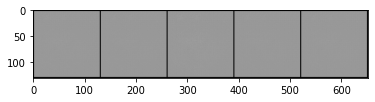

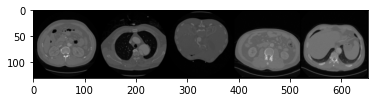

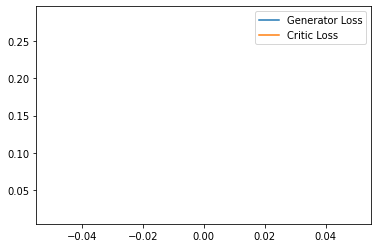

Epoch 0, step 50: Generator loss: -0.007496271878480911, critic loss: 2.4140649394989016


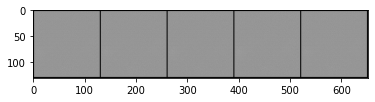

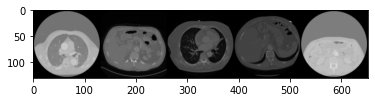

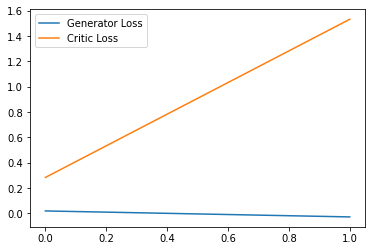

Epoch 0, step 75: Generator loss: 0.07796091567724943, critic loss: 0.6602652144432067


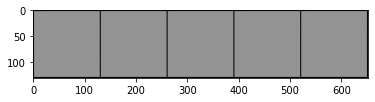

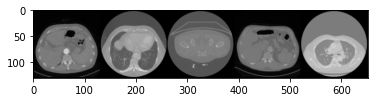

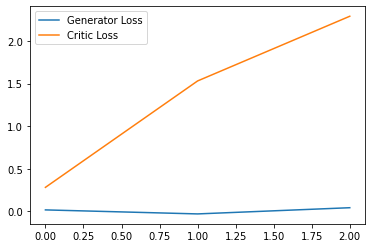

Epoch 0, step 100: Generator loss: 0.03873540757223964, critic loss: 0.5598870717287063


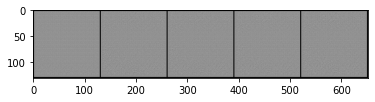

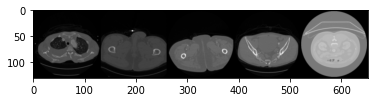

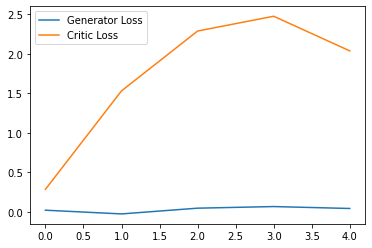

Epoch 0, step 125: Generator loss: 0.16390590835362673, critic loss: -0.18995223093032834


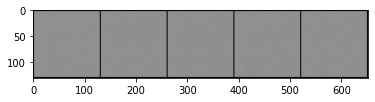

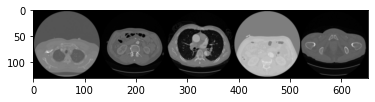

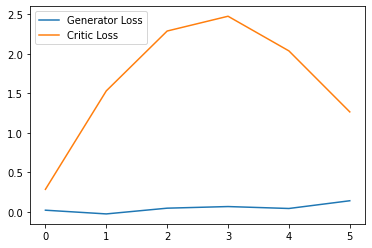

Epoch 0, step 150: Generator loss: 0.6563748693466187, critic loss: -1.6455772075653075


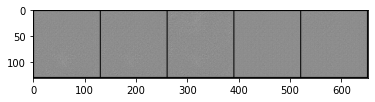

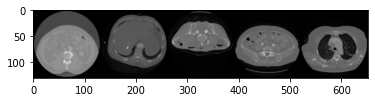

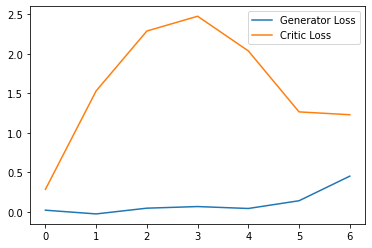

Epoch 0, step 175: Generator loss: 1.9939105224609375, critic loss: -5.3313192214965825


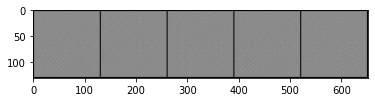

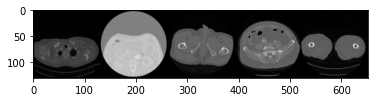

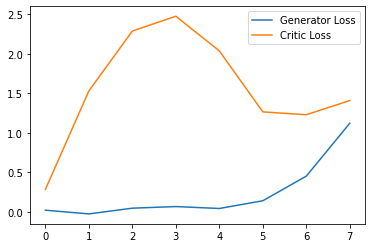

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 1, step 200: Generator loss: 4.831805944442749, critic loss: -11.333655258178712


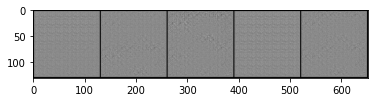

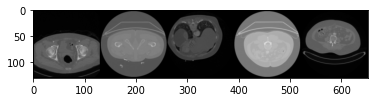

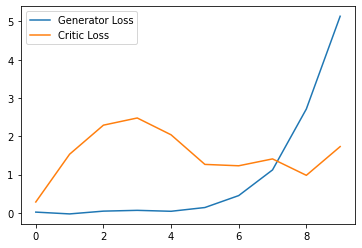

Epoch 1, step 225: Generator loss: 8.98395565032959, critic loss: -20.7440647277832


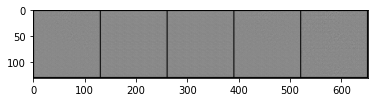

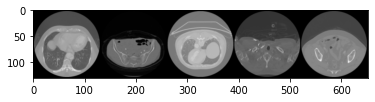

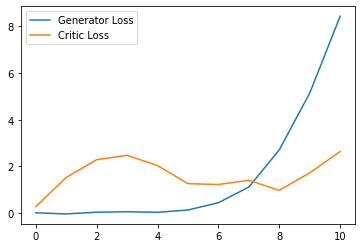

Epoch 1, step 250: Generator loss: 14.715625343322754, critic loss: -31.88065945434571


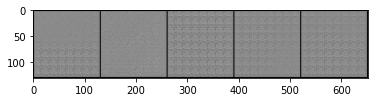

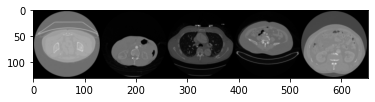

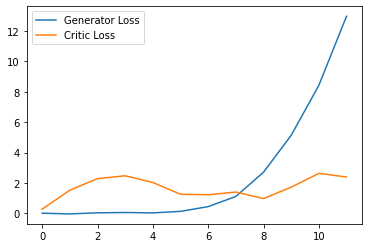

Epoch 1, step 275: Generator loss: 21.270372924804686, critic loss: -45.37917895507813


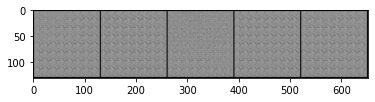

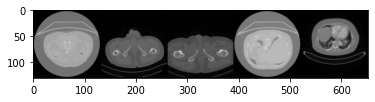

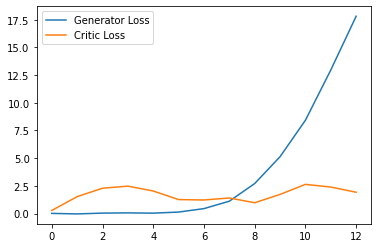

Epoch 1, step 300: Generator loss: 29.79288589477539, critic loss: -60.902939575195305


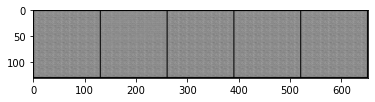

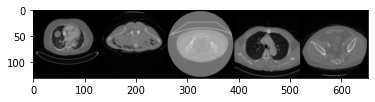

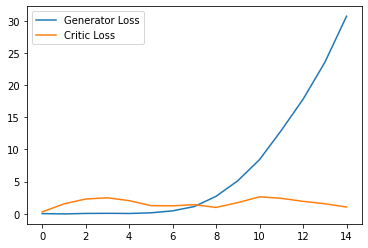

Epoch 1, step 325: Generator loss: 40.794312438964845, critic loss: -80.26380456542967


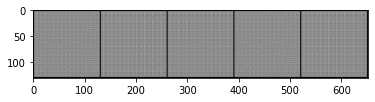

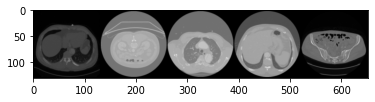

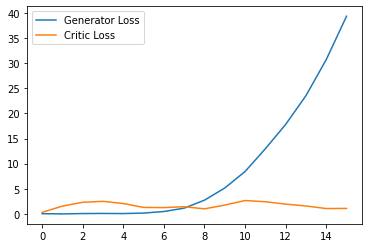

Epoch 1, step 350: Generator loss: 54.52778106689453, critic loss: -101.99161413574218


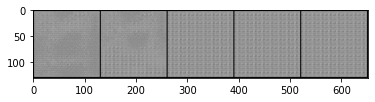

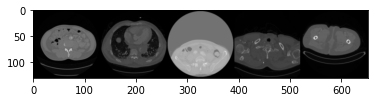

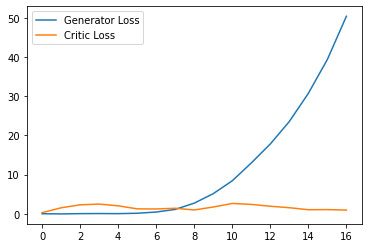

Epoch 1, step 375: Generator loss: 68.00391632080078, critic loss: -126.06878881835935


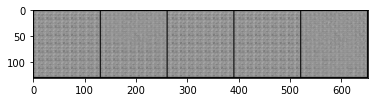

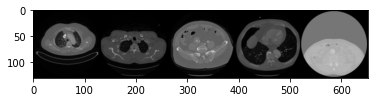

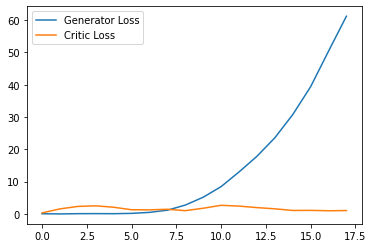

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 2, step 400: Generator loss: 81.50619110107422, critic loss: -147.28644055175783


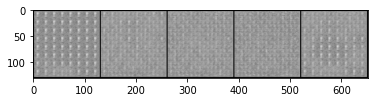

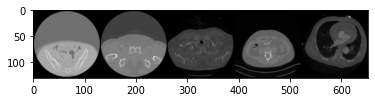

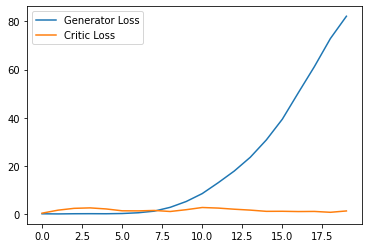

Epoch 2, step 425: Generator loss: 96.70154846191406, critic loss: -179.05459130859373


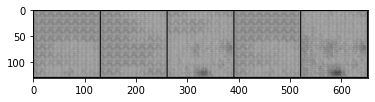

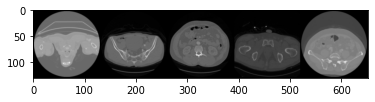

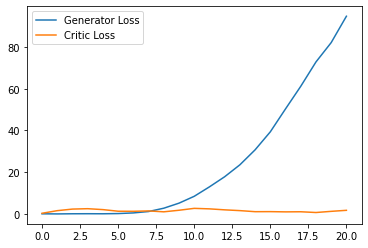

Epoch 2, step 450: Generator loss: 115.70573699951171, critic loss: -211.22020068359373


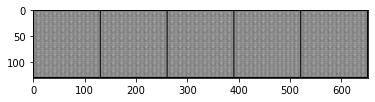

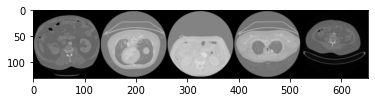

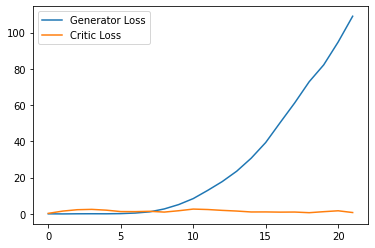

Epoch 2, step 475: Generator loss: 139.0849072265625, critic loss: -238.2300935058594


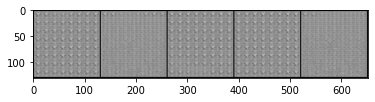

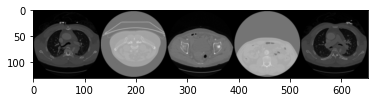

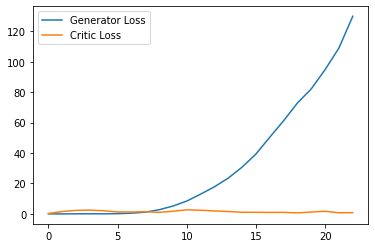

Epoch 2, step 500: Generator loss: 151.12863037109375, critic loss: -276.87469677734373


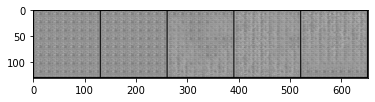

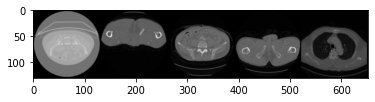

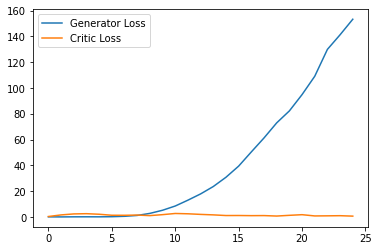

Epoch 2, step 525: Generator loss: 176.75017883300782, critic loss: -315.0661489257813


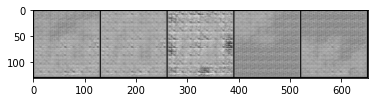

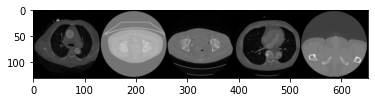

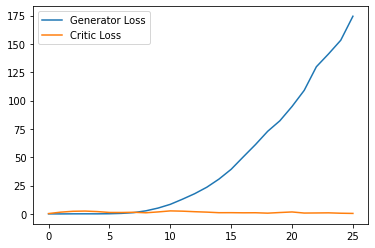

Epoch 2, step 550: Generator loss: 197.3108624267578, critic loss: -321.4306271972656


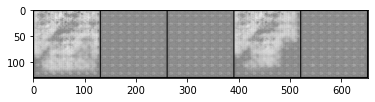

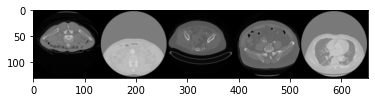

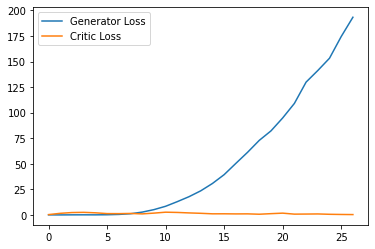

Epoch 2, step 575: Generator loss: 190.85877517700195, critic loss: -235.76123193359376


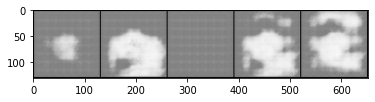

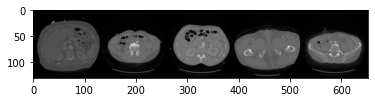

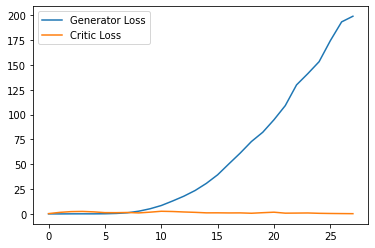

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 3, step 600: Generator loss: 223.75035217285156, critic loss: -390.28568334960937


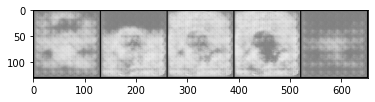

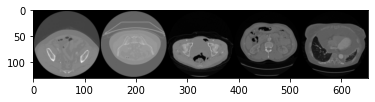

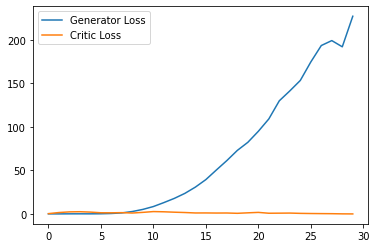

Epoch 3, step 625: Generator loss: 249.44052978515626, critic loss: -441.99582910156255


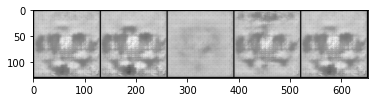

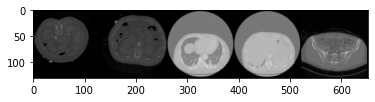

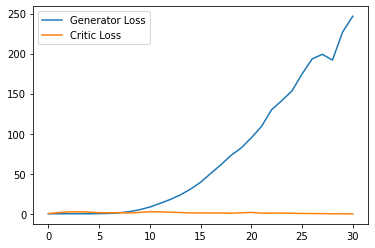

Epoch 3, step 650: Generator loss: 271.09021362304685, critic loss: -485.94861279296885


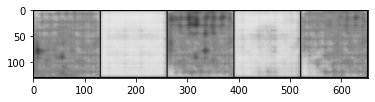

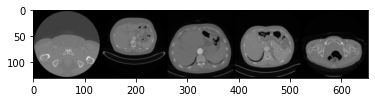

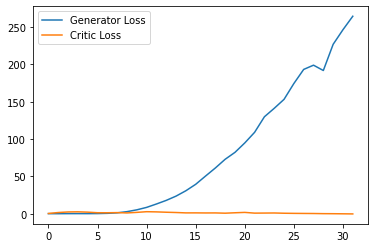

Epoch 3, step 675: Generator loss: 295.87286254882815, critic loss: -522.3381748046875


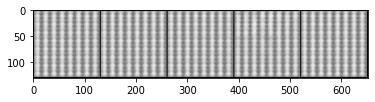

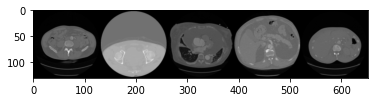

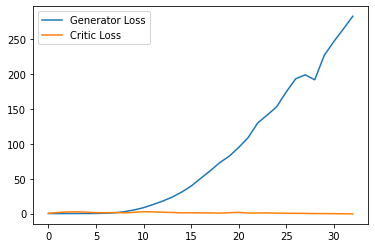

Epoch 3, step 700: Generator loss: 327.9318017578125, critic loss: -586.1188320312499


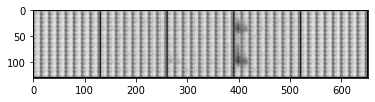

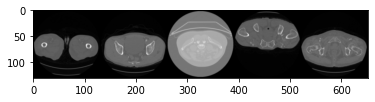

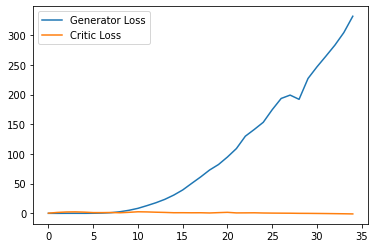

Epoch 3, step 725: Generator loss: 377.2399536132813, critic loss: -615.8986186523438


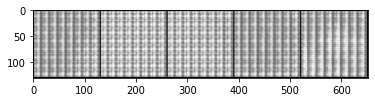

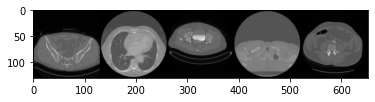

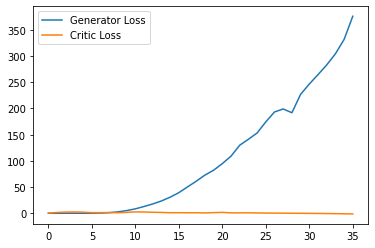

Epoch 3, step 750: Generator loss: 385.03582275390625, critic loss: -668.3073950195312


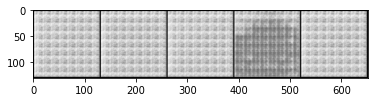

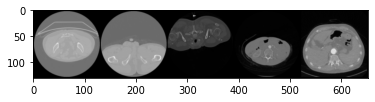

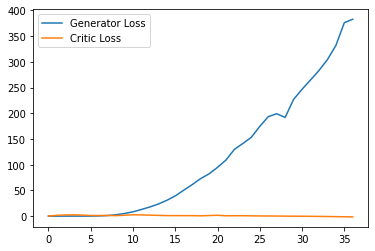

Epoch 3, step 775: Generator loss: 405.2439221191406, critic loss: -522.7160795898438


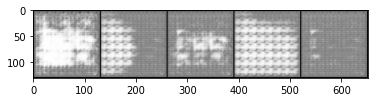

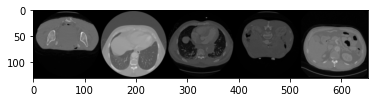

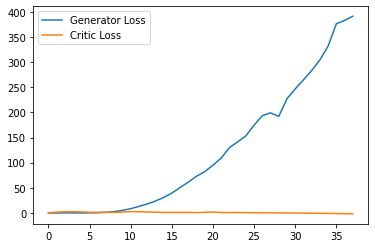

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 4, step 800: Generator loss: 483.37848205566405, critic loss: -711.0863525390625


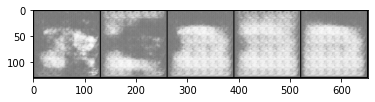

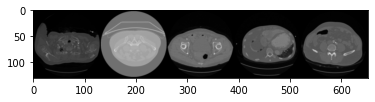

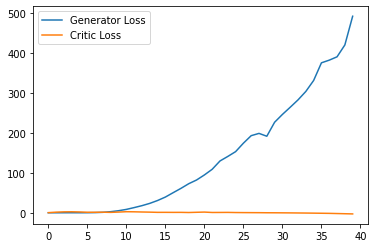

Epoch 4, step 825: Generator loss: 462.96993041992187, critic loss: -786.5721010742186


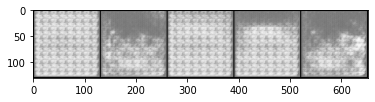

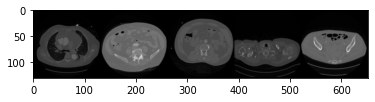

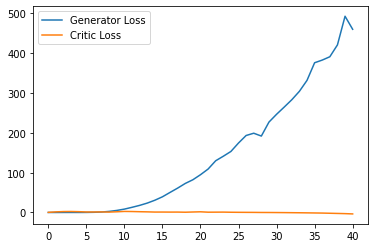

Epoch 4, step 850: Generator loss: 487.1502209472656, critic loss: -854.263095703125


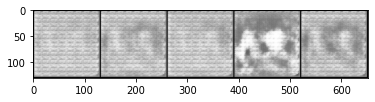

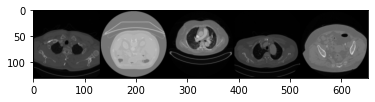

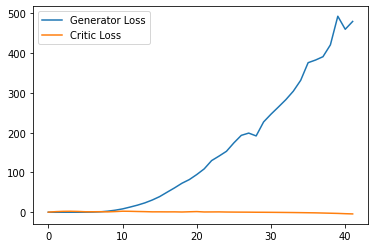

Epoch 4, step 875: Generator loss: 512.9797143554688, critic loss: -891.2694892578126


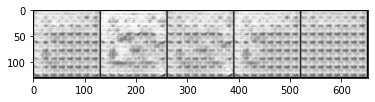

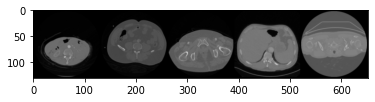

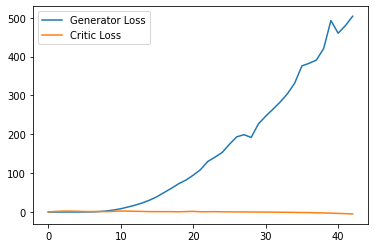

Epoch 4, step 900: Generator loss: 547.9468981933594, critic loss: -936.2425966796877


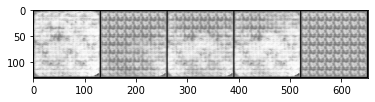

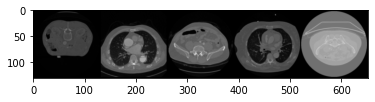

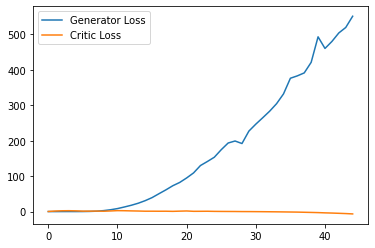

Epoch 4, step 925: Generator loss: 579.0553112792969, critic loss: -894.3731640625001


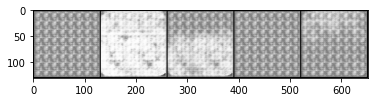

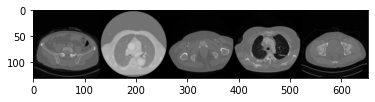

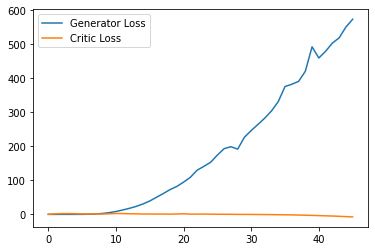

Epoch 4, step 950: Generator loss: 600.0416430664062, critic loss: -1031.9043515624999


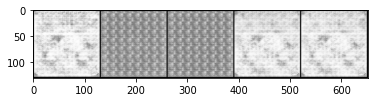

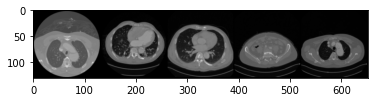

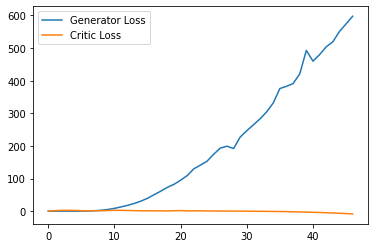

Epoch 4, step 975: Generator loss: 617.929296875, critic loss: -1133.4819111328125


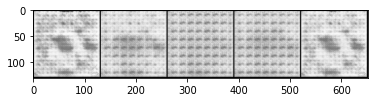

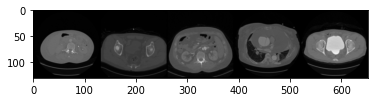

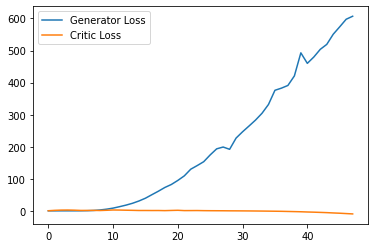

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 5, step 1000: Generator loss: 635.8867993164063, critic loss: -1157.5288642578123


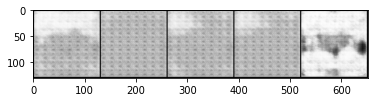

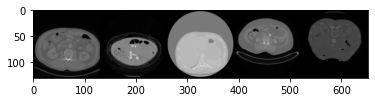

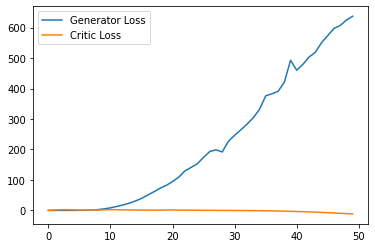

Epoch 5, step 1025: Generator loss: 670.1441357421875, critic loss: -1206.9138037109374


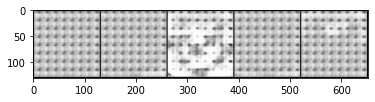

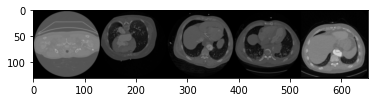

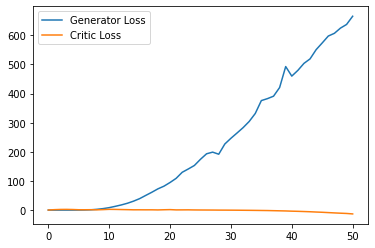

Epoch 5, step 1050: Generator loss: 710.667021484375, critic loss: -1255.8655751953127


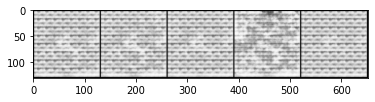

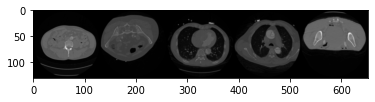

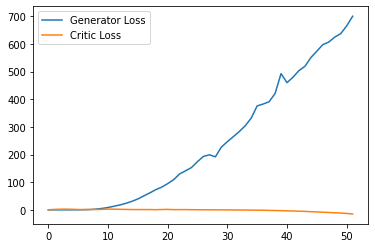

Epoch 5, step 1075: Generator loss: 732.7746020507813, critic loss: -1339.6082373046875


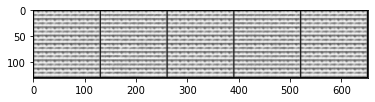

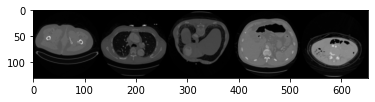

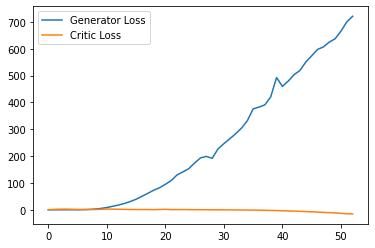

Epoch 5, step 1100: Generator loss: 773.0565161132813, critic loss: -1371.3612392578125


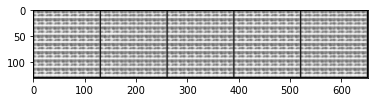

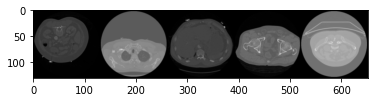

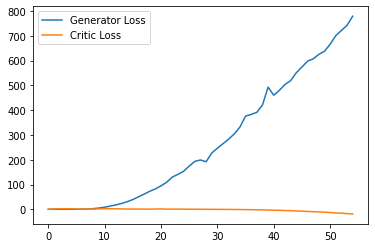

Epoch 5, step 1125: Generator loss: 805.2879760742187, critic loss: -1441.0026406249997


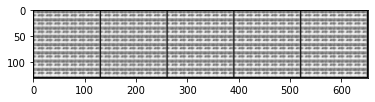

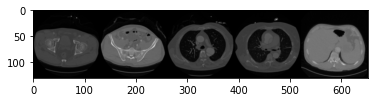

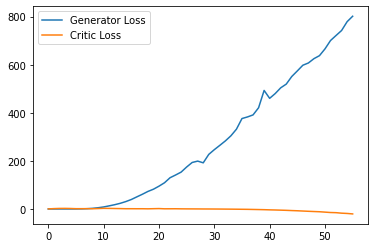

Epoch 5, step 1150: Generator loss: 852.164951171875, critic loss: -1508.8513203125


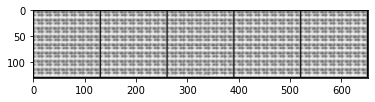

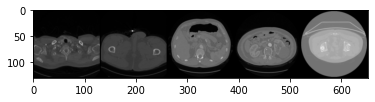

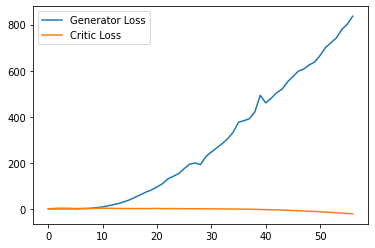

Epoch 5, step 1175: Generator loss: 914.8704760742188, critic loss: -1598.4049570312502


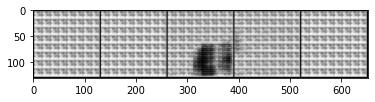

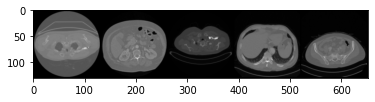

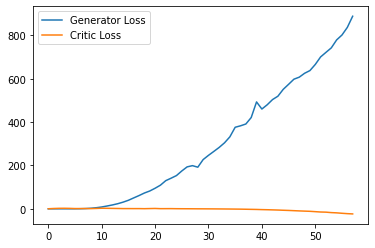

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 6, step 1200: Generator loss: 934.5094116210937, critic loss: -1656.49089453125


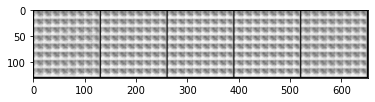

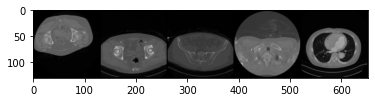

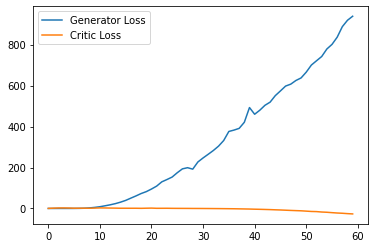

Epoch 6, step 1225: Generator loss: 984.3621752929688, critic loss: -1717.1710781250001


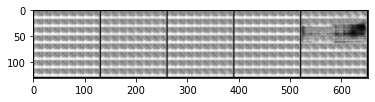

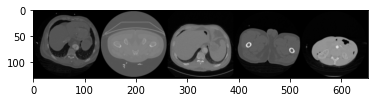

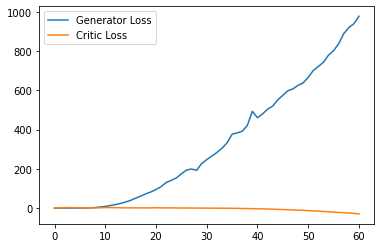

Epoch 6, step 1250: Generator loss: 1061.4878100585938, critic loss: -1783.3515468750002


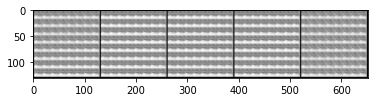

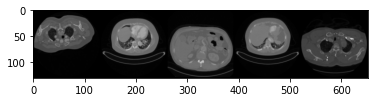

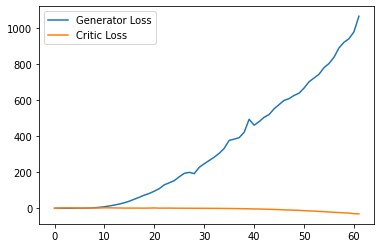

Epoch 6, step 1275: Generator loss: 1050.3728295898438, critic loss: -1799.02181640625


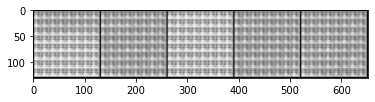

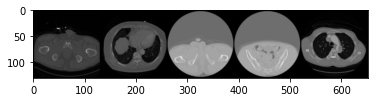

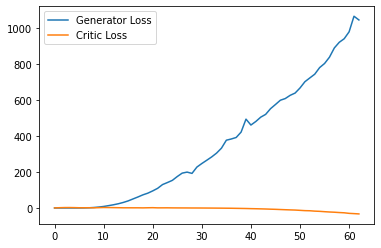

Epoch 6, step 1300: Generator loss: 1031.5456396484376, critic loss: -1933.6276621093753


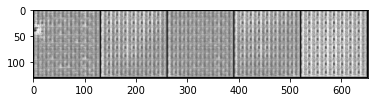

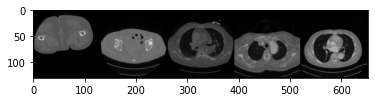

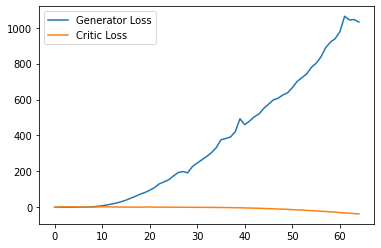

Epoch 6, step 1325: Generator loss: 1069.908623046875, critic loss: -1967.654560546875


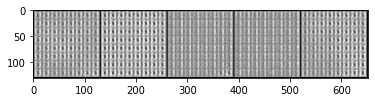

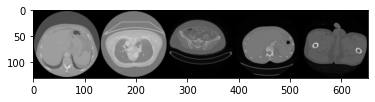

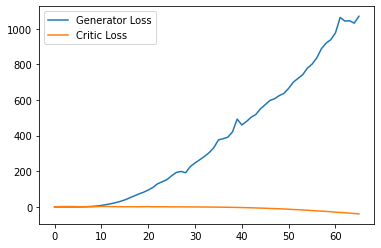

Epoch 6, step 1350: Generator loss: 1098.512236328125, critic loss: -2013.7047949218747


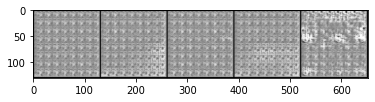

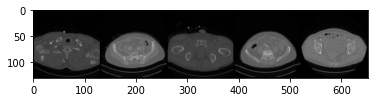

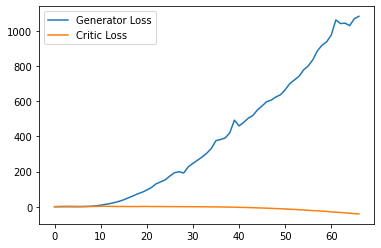

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 7, step 1375: Generator loss: 1104.1153271484375, critic loss: -2068.4690859375


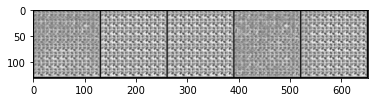

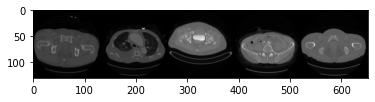

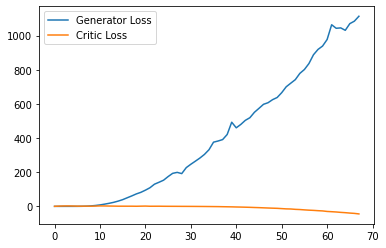

Epoch 7, step 1400: Generator loss: 1127.6883251953125, critic loss: -1888.7839960937501


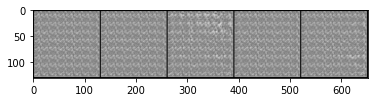

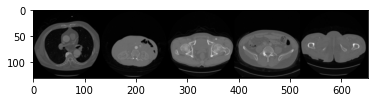

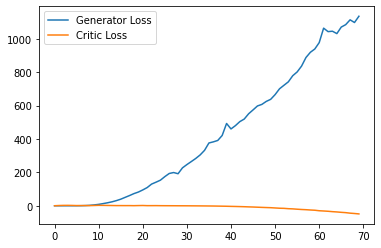

Epoch 7, step 1425: Generator loss: 1178.1096630859374, critic loss: -2187.98751953125


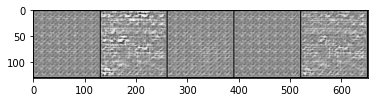

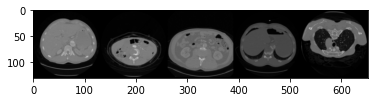

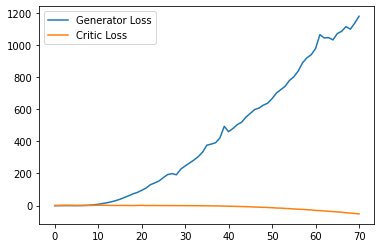

Epoch 7, step 1450: Generator loss: 1195.9310009765625, critic loss: -2235.971357421875


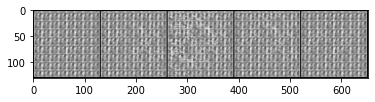

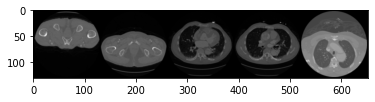

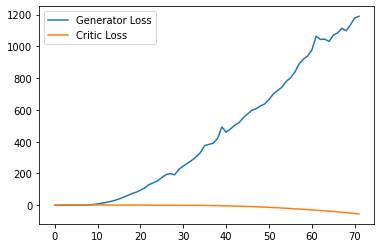

Epoch 7, step 1475: Generator loss: 1225.369970703125, critic loss: -2272.038662109375


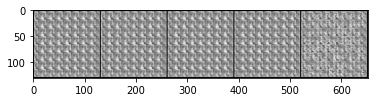

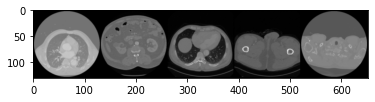

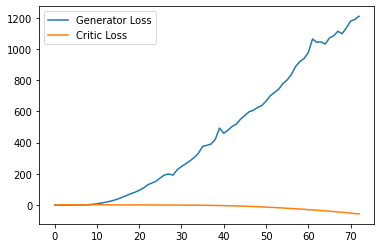

Epoch 7, step 1500: Generator loss: 1202.8917333984375, critic loss: -2353.7662675781253


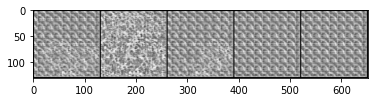

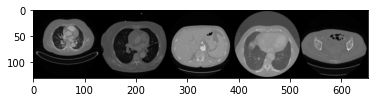

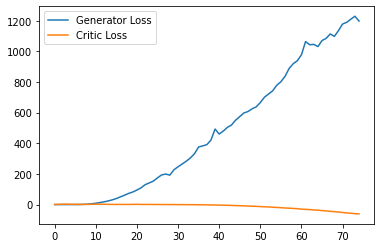

Epoch 7, step 1525: Generator loss: 1221.839990234375, critic loss: -2356.774498046875


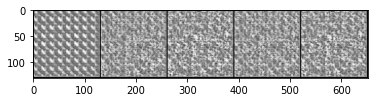

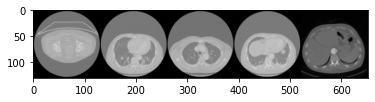

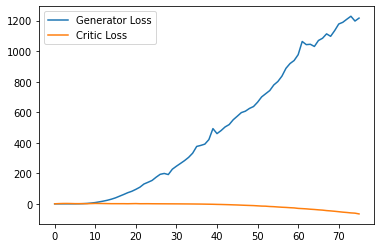

Epoch 7, step 1550: Generator loss: 1214.14068359375, critic loss: -2491.9529628906253


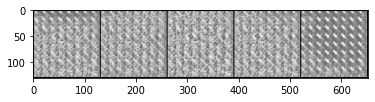

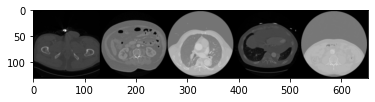

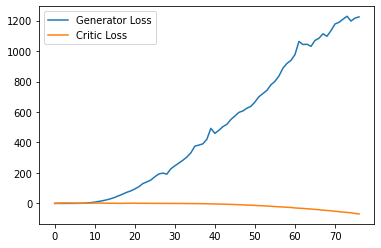

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 8, step 1575: Generator loss: 1211.8694482421874, critic loss: -2528.9754296875


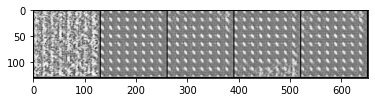

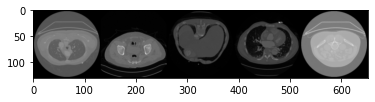

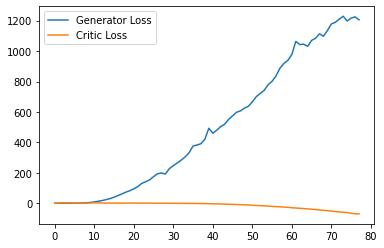

Epoch 8, step 1600: Generator loss: 1253.4981103515624, critic loss: -2561.7716660156248


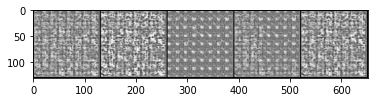

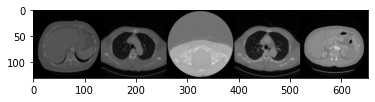

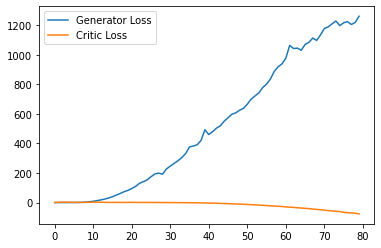

Epoch 8, step 1625: Generator loss: 1271.6180712890625, critic loss: -2661.8788750000003


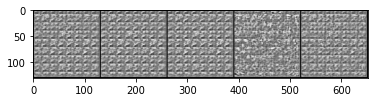

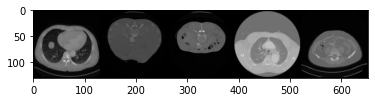

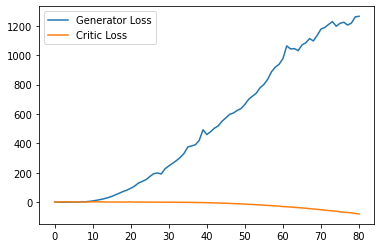

Epoch 8, step 1650: Generator loss: 1308.793544921875, critic loss: -2722.0793632812497


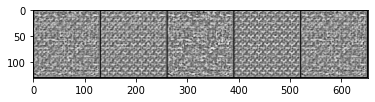

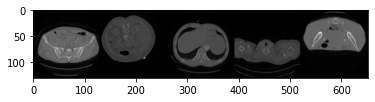

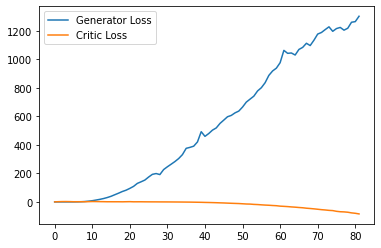

Epoch 8, step 1675: Generator loss: 1332.0467578125, critic loss: -2391.5768012695316


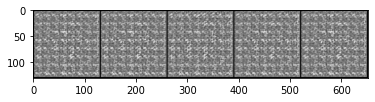

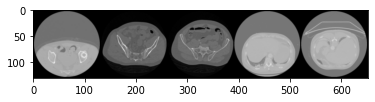

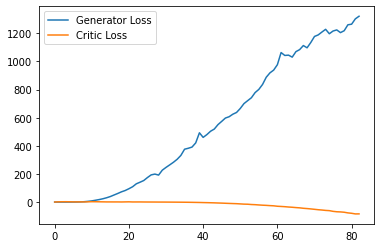

Epoch 8, step 1700: Generator loss: 1322.2161181640624, critic loss: -2667.27603515625


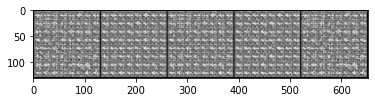

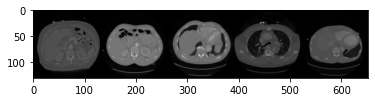

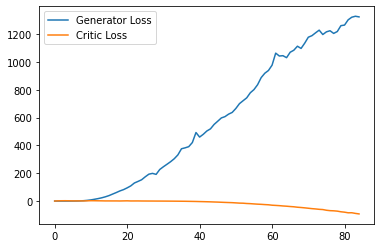

Epoch 8, step 1725: Generator loss: 1393.697734375, critic loss: -2762.34813671875


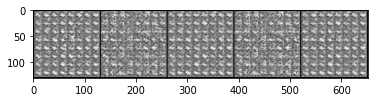

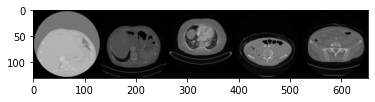

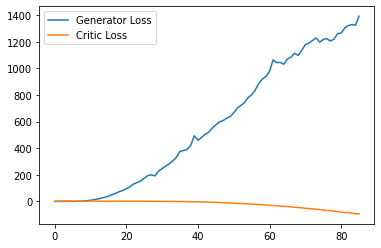

Epoch 8, step 1750: Generator loss: 1396.3011083984375, critic loss: -2883.6010625


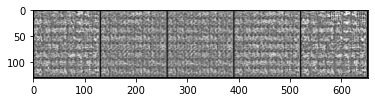

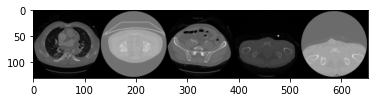

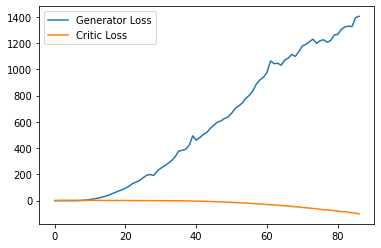

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 9, step 1775: Generator loss: 1405.4047802734376, critic loss: -2833.304234375


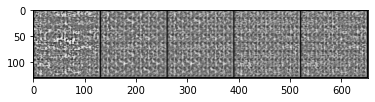

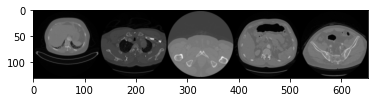

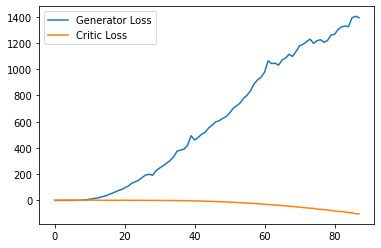

Epoch 9, step 1800: Generator loss: 1432.917607421875, critic loss: -2953.4249765625004


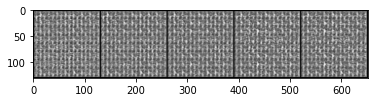

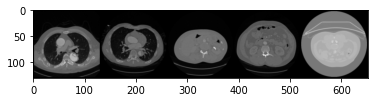

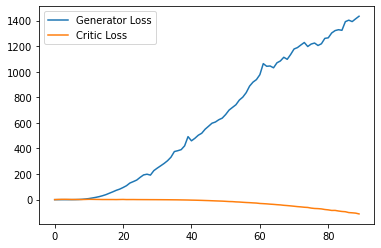

Epoch 9, step 1825: Generator loss: 1420.01767578125, critic loss: -3038.26887890625


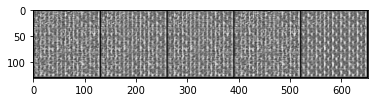

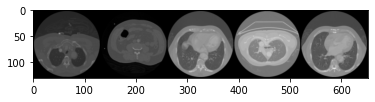

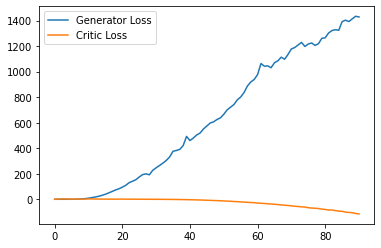

Epoch 9, step 1850: Generator loss: 1391.8559375, critic loss: -3079.0272460937495


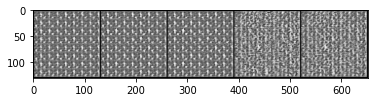

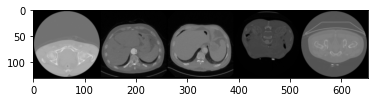

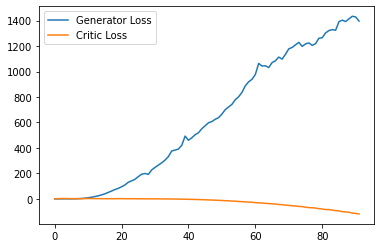

Epoch 9, step 1875: Generator loss: 1380.08794921875, critic loss: -2781.402251953126


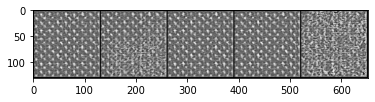

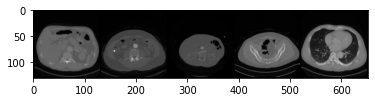

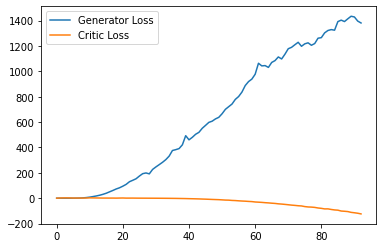

Epoch 9, step 1900: Generator loss: 1403.064033203125, critic loss: -3242.0097109375


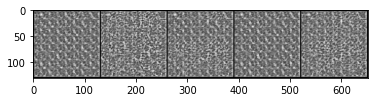

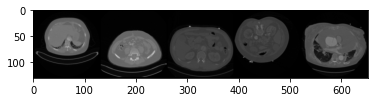

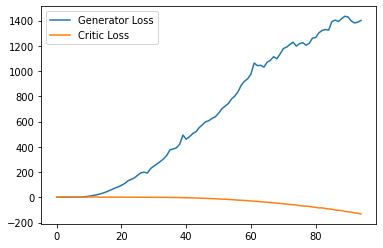

Epoch 9, step 1925: Generator loss: 1397.900068359375, critic loss: -3214.32914453125


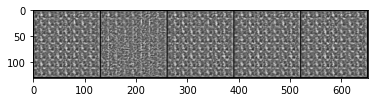

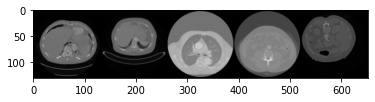

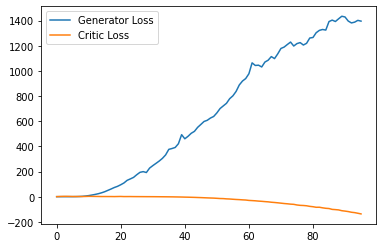

Epoch 9, step 1950: Generator loss: 1396.6572509765624, critic loss: -3184.1339746093745


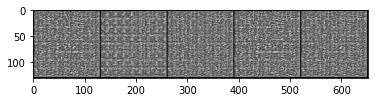

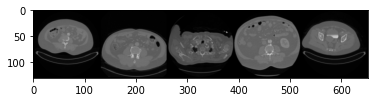

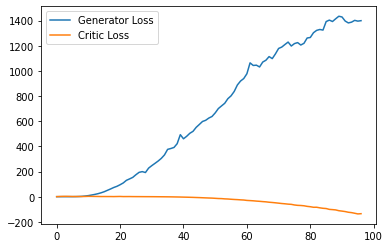

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 10, step 1975: Generator loss: 1392.4572607421876, critic loss: -3177.2675


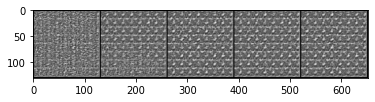

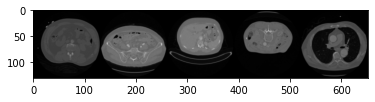

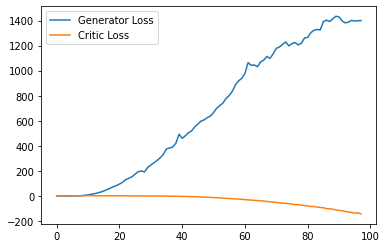

Epoch 10, step 2000: Generator loss: 1399.219990234375, critic loss: -3373.96865234375


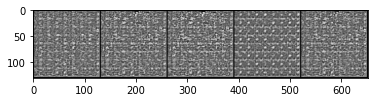

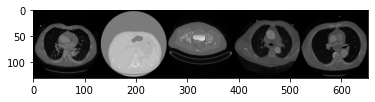

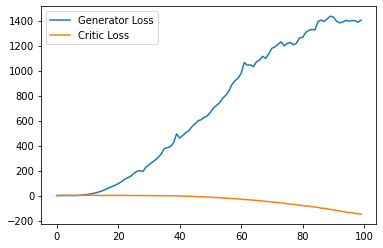

Epoch 10, step 2025: Generator loss: 1467.9420849609376, critic loss: -3471.9336445312492


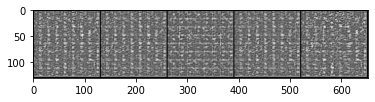

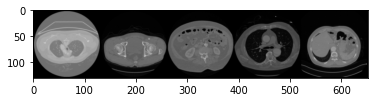

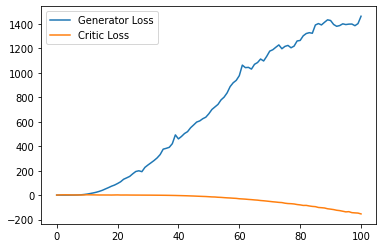

Epoch 10, step 2050: Generator loss: 1426.6910546875, critic loss: -3537.7072109375


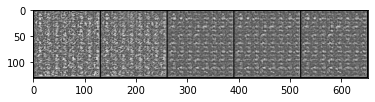

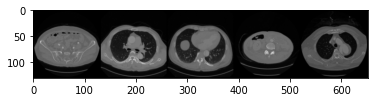

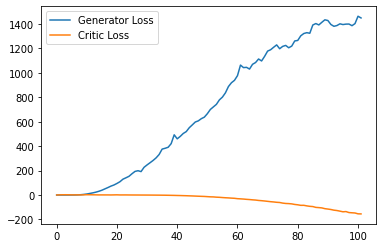

Epoch 10, step 2075: Generator loss: 1406.267646484375, critic loss: -3593.3653828125007


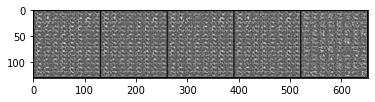

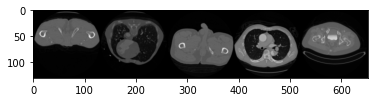

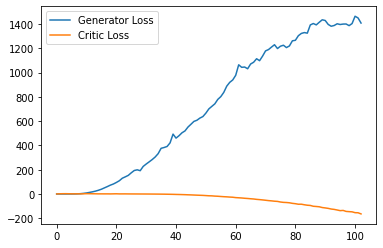

Epoch 10, step 2100: Generator loss: 1441.4365380859374, critic loss: -3659.5186328124996


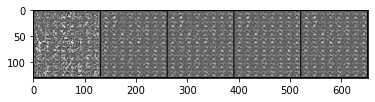

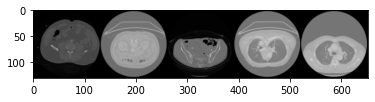

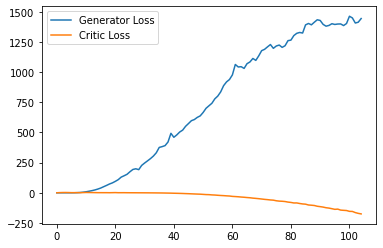

Epoch 10, step 2125: Generator loss: 1445.8977685546874, critic loss: -3616.071394531251


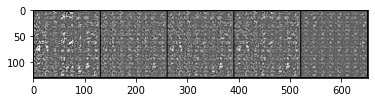

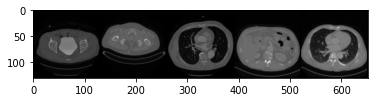

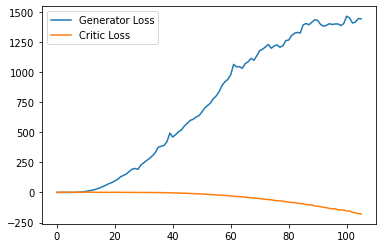

Epoch 10, step 2150: Generator loss: 1488.330595703125, critic loss: -3702.0956953124987


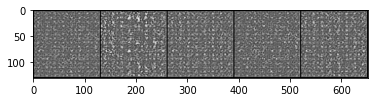

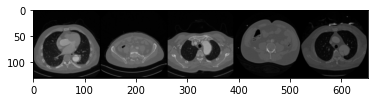

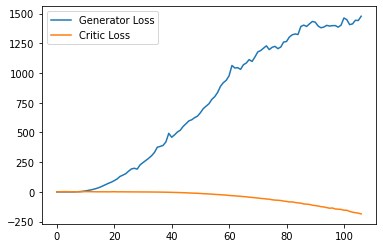

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 11, step 2175: Generator loss: 1499.948115234375, critic loss: -3748.7265898437495


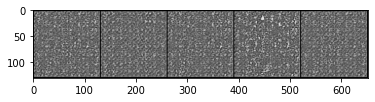

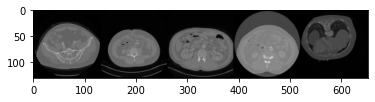

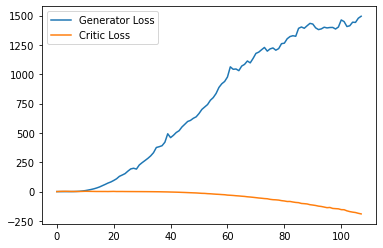

Epoch 11, step 2200: Generator loss: 1501.0548828125, critic loss: -3777.8607460937496


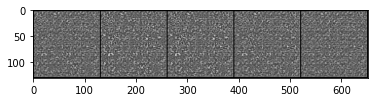

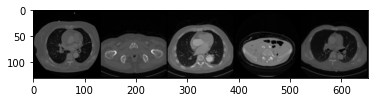

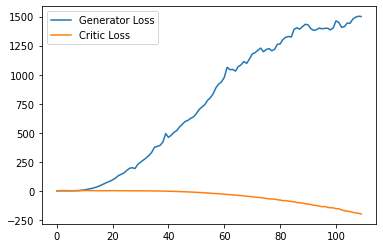

Epoch 11, step 2225: Generator loss: 1524.4739208984374, critic loss: -3799.4084921875


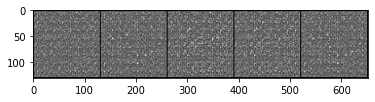

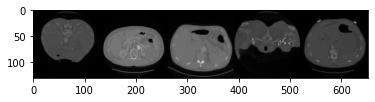

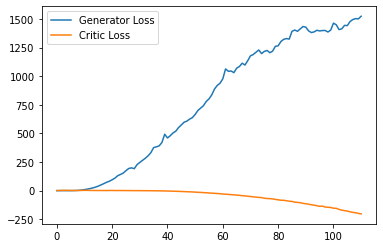

Epoch 11, step 2250: Generator loss: 1545.2074951171876, critic loss: -3880.61460546875


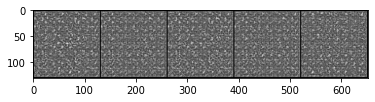

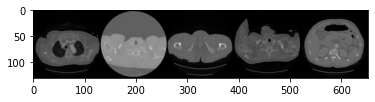

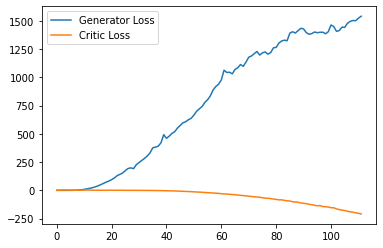

Epoch 11, step 2275: Generator loss: 1564.00779296875, critic loss: -3877.5280742187488


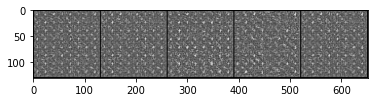

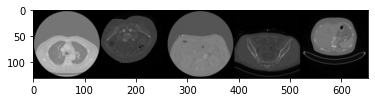

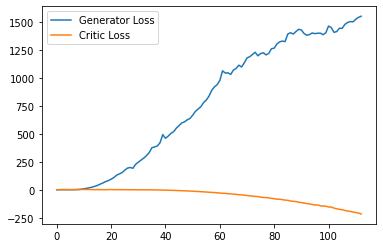

Epoch 11, step 2300: Generator loss: 1546.2589013671875, critic loss: -3902.292894531251


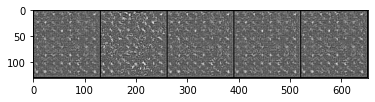

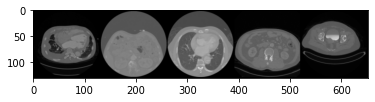

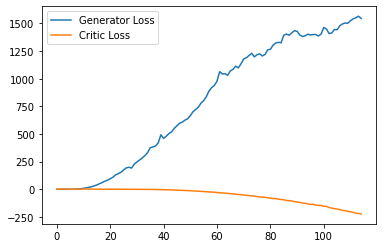

Epoch 11, step 2325: Generator loss: 1559.438798828125, critic loss: -4103.1761875


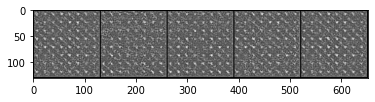

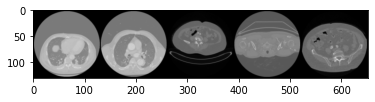

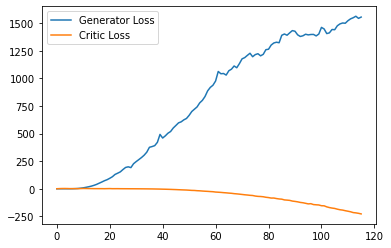

Epoch 11, step 2350: Generator loss: 1575.2206884765626, critic loss: -4159.631820312499


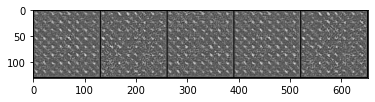

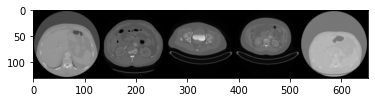

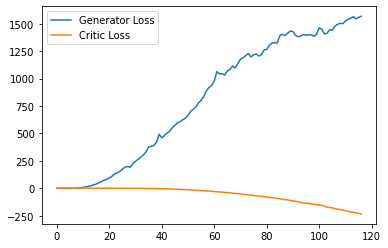

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch 12, step 2375: Generator loss: 1578.0584814453125, critic loss: -4174.54313671875


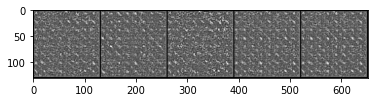

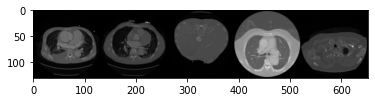

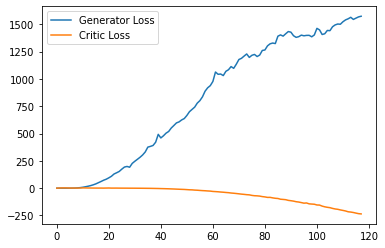

Epoch 12, step 2400: Generator loss: 1596.775576171875, critic loss: -4264.886535156249


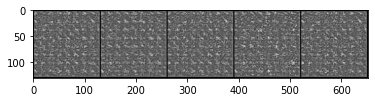

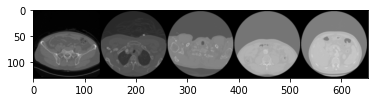

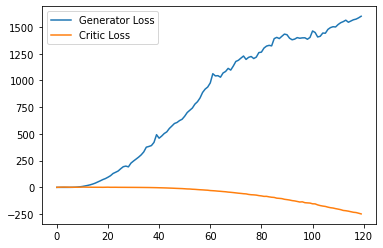

Epoch 12, step 2425: Generator loss: 1611.5772021484374, critic loss: -4130.83780859375


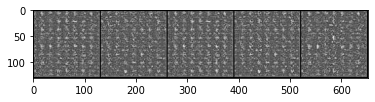

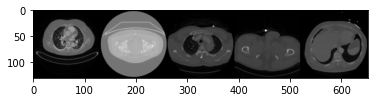

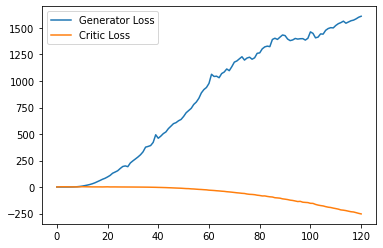

Epoch 12, step 2450: Generator loss: 1620.4535986328126, critic loss: -4371.071410156251


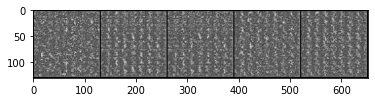

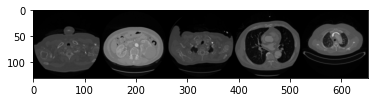

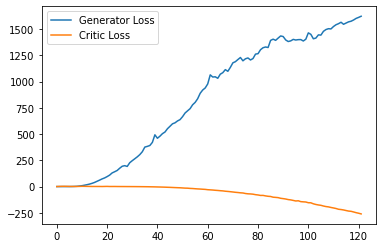

Epoch 12, step 2475: Generator loss: 1635.2341015625, critic loss: -4072.44090625


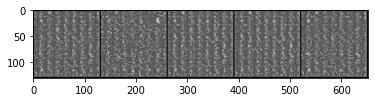

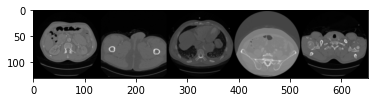

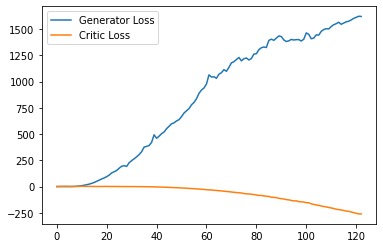

KeyboardInterrupt: 

In [16]:
gen, crit, gen_opt, crit_opt = GAN(trained, epochs, display_step, img_channels, crit_repeats, learning_rate_G, learning_rate_D, beta_1, beta_2, lambda_, z_dim, size, dataloader, loss, device)

In [14]:
generator = Generator(z_dim, img_channels).to(device)
generator.load_state_dict(torch.load('Generator_128_W_e.pth'))

<All keys matched successfully>

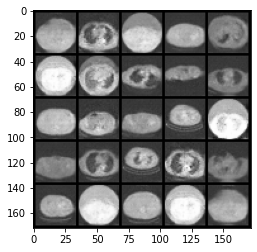

In [16]:
generate_images(generator, 25, z_dim, num_images = 25, size = size, device = device)